In [1]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)


import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/hughiephan/moving-mnist/mnist_1d64_4.npz
/kaggle/input/datasets/hughiephan/moving-mnist/mnist_1d64_3.npz
/kaggle/input/datasets/hughiephan/moving-mnist/mnist_1d64_0.npz
/kaggle/input/datasets/hughiephan/moving-mnist/mnist_1d64_1.npz
/kaggle/input/datasets/hughiephan/moving-mnist/mnist_1d64_2.npz


In [2]:
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader
import random

class MovingMNISTDataset(Dataset):
    def __init__(self, npz_path):
        # 1. Load the compressed numpy file
        data = np.load(npz_path)
        
        # .npz files contain multiple arrays accessed by keys. 
        # Usually, the main data is under 'arr_0', 'clips', or similar.
        key = data.files[0] 
        raw_videos = data[key]
        raw_videos = np.swapaxes(raw_videos, -2, -1)  
        self.videos = raw_videos.reshape(-1, 20, 64, 64)
        print(f"Loaded raw data shape: {self.videos.shape}")


    def __len__(self):
        return len(self.videos)

    def __getitem__(self, idx):
        # Extract the sequence: [Frames, H, W]
        video = self.videos[idx] 
        
        # Convert to PyTorch tensor
        tensor_video = torch.tensor(video, dtype=torch.float32)

        # cropping to 16 frames
        start_idx = random.randint(0, 4)
        tensor_video = tensor_video[start_idx:start_idx+16, :, :]
        
        # Add the Channel dimension required by Conv3d: [1, Frames, H, W]
        tensor_video = tensor_video.unsqueeze(0)
        
        # Normalize pixel values from [0, 255] to [-1, 1]. 
        # Neural networks and Flow Matching perform much better with zero-centered data.
        tensor_video = (tensor_video / 127.5) - 1.0
        
        return tensor_video

In [3]:
import torch.nn.functional as F
from torch.optim import AdamW

# --- Configuration ---
NPZ_PATH = '/kaggle/input/datasets/hughiephan/moving-mnist/mnist_1d64_4.npz'
BATCH_SIZE = 16
LEARNING_RATE = 1e-4
EPOCHS = 10
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# --- Setup Data ---
dataset = MovingMNISTDataset(NPZ_PATH)

Loaded raw data shape: (10000, 20, 64, 64)


Corrected Video Dataset Shape: (10000, 20, 1, 64, 64)


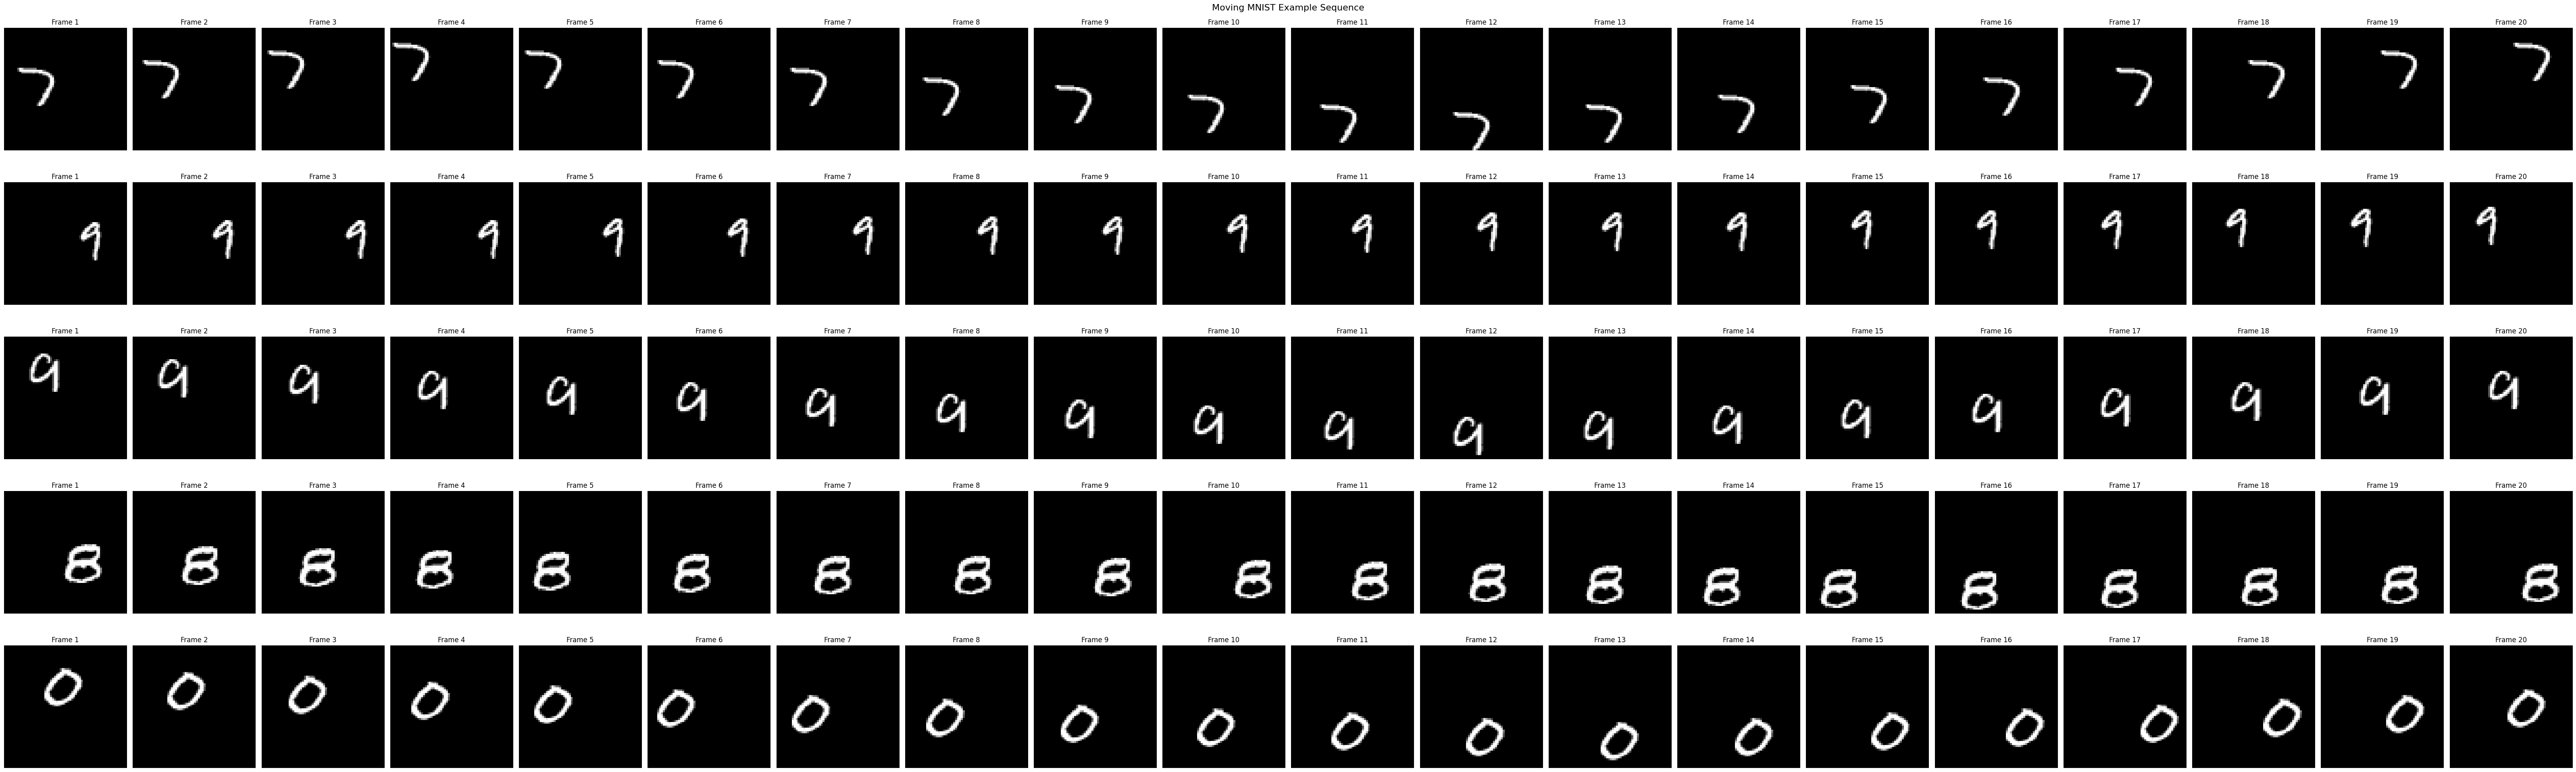

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import imageio

# 1. Load the raw data
data = np.load('/kaggle/input/datasets/hughiephan/moving-mnist/mnist_1d64_4.npz')
key = data.files[0]
raw_data = data[key]  # Shape: (200000, 1, 64, 64)

# 2. Reshape into videos
# We group every 4 consecutive frames into a single video sequence.
# New shape: (50000 videos, 4 frames, 1 channel, 64 height, 64 width)
raw_data = np.swapaxes(raw_data, -2, -1)
videos = raw_data.reshape(-1, 20, 1, 64, 64)
print(f"Corrected Video Dataset Shape: {videos.shape}")

# 3. Select an example video (let's grab the first one)
example_video = videos[0] # Shape: (4, 1, 64, 64)

# 4. Plot the frames side-by-side
fig, axes = plt.subplots(5, 20, figsize=(64, 20))
fig.suptitle("Moving MNIST Example Sequence", fontsize=16)

for j in range(5):
    example_video = videos[j+100] # Shape: (4, 1, 64, 64)
    for i in range(20):
        # Squeeze out the channel dimension so matplotlib can plot a 2D (64, 64) image
        frame = example_video[i].squeeze() 
        axes[j][i].imshow(frame, cmap='gray')
        axes[j][i].set_title(f"Frame {i+1}")
        axes[j][i].axis('off')

plt.tight_layout()
plt.show()